# Notebook 08 — Yoshida 4th-Order Symplectic Integrator

Demonstrates the Yoshida 4th-order integrator and its advantage over Leapfrog for
long-term integrations.

**Key question:** Given the same timestep, how much better is Yoshida4's energy
conservation compared to Leapfrog?

**System:** Earth-Moon (3 bodies) and Solar System (10 bodies)  
**Metric:** Relative energy drift `|ΔE/E₀|` over time  
**Reference:** Yoshida, H. (1990) — *Construction of higher order symplectic integrators*

See `docs/yoshida.md` for the physics background and derivation of the coefficients.

In [9]:
import os
if os.path.basename(os.getcwd()) == 'examples':
    os.chdir('..')

In [10]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import orbit

YEAR = 365.25 * 24 * 3600

print(f'orbit {orbit.__version__}')
print(f'Available integrators: {[x for x in dir(orbit.Integrator) if not x.startswith("_")]}')

orbit 2.0.0
Available integrators: ['Euler', 'Leapfrog', 'RK4', 'RK45', 'Yoshida4', 'name', 'value']


## 1 — Energy drift over 1 year (Earth-Moon, dt=1h)

Same timestep, same system. Yoshida4 uses 3× more force evaluations per step but
achieves O(dt⁵) error vs Leapfrog's O(dt³).

In [11]:
SYSTEM = 'systems/earth_moon.json'
STEPS  = 8760   # 1 year at dt=1h
DT     = 3600.0

r_lf = orbit.simulate(SYSTEM, steps=STEPS, dt=DT, integrator=orbit.Integrator.Leapfrog)
r_y4 = orbit.simulate(SYSTEM, steps=STEPS, dt=DT, integrator=orbit.Integrator.Yoshida4)

t_yr = np.array([s.time_s for s in r_lf.snapshots]) / YEAR

e_lf = r_lf.energies_numpy()
e_y4 = r_y4.energies_numpy()

dE_lf = np.abs((e_lf - e_lf[0]) / e_lf[0])
dE_y4 = np.abs((e_y4 - e_y4[0]) / e_y4[0])

print(f'Leapfrog  max |dE/E| = {np.max(dE_lf):.3e}')
print(f'Yoshida4  max |dE/E| = {np.max(dE_y4):.3e}')
print(f'Improvement factor   = {np.max(dE_lf) / np.max(dE_y4):.0f}x')

Leapfrog  max |dE/E| = 2.799e-10
Yoshida4  max |dE/E| = 4.495e-14
Improvement factor   = 6227x


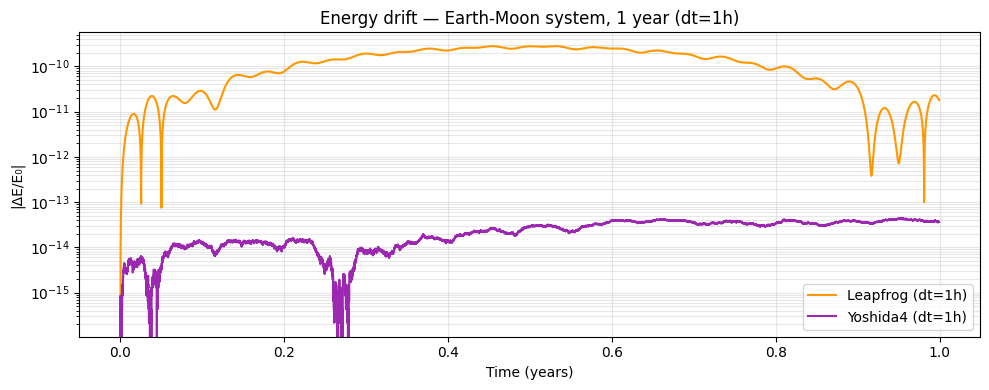

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.semilogy(t_yr, dE_lf, label='Leapfrog (dt=1h)', color='#FF9800', linewidth=1.5)
ax.semilogy(t_yr, dE_y4, label='Yoshida4 (dt=1h)', color='#9C27B0', linewidth=1.5)

ax.set_xlabel('Time (years)')
ax.set_ylabel('|ΔE/E₀|')
ax.set_title('Energy drift — Earth-Moon system, 1 year (dt=1h)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 2 — Equal-cost comparison

Yoshida4 uses 3 force evaluations per step vs 1 for Leapfrog. To make a fair
cost comparison, we give Leapfrog 3× more steps (smaller dt) for the same total
number of force evaluations.

| Integrator | dt | Steps/year | Force evals/year |
|---|---|---|---|
| Leapfrog | 1h | 8,760 | 8,760 |
| Yoshida4 | 3h | 2,920 | 8,760 |

Same total cost — which gives better energy conservation?

In [13]:
# Leapfrog at dt=1h: 8760 force evals/year
# Yoshida4 at dt=3h: 2920 steps × 3 evals = 8760 force evals/year  ← equal cost

r_lf_1h = orbit.simulate(SYSTEM, steps=8760,  dt=3600.0,  integrator=orbit.Integrator.Leapfrog)
r_lf_3h = orbit.simulate(SYSTEM, steps=2920,  dt=10800.0, integrator=orbit.Integrator.Leapfrog)
r_y4_3h = orbit.simulate(SYSTEM, steps=2920,  dt=10800.0, integrator=orbit.Integrator.Yoshida4)

def drift(r):
    e = r.energies_numpy()
    return np.abs((e - e[0]) / e[0])

def t_years(r):
    return np.array([s.time_s for s in r.snapshots]) / YEAR

print(f'Leapfrog (dt=1h)  max |dE/E| = {np.max(drift(r_lf_1h)):.3e}')
print(f'Leapfrog (dt=3h)  max |dE/E| = {np.max(drift(r_lf_3h)):.3e}  ← same cost as Yoshida4 (dt=3h)')
print(f'Yoshida4 (dt=3h)  max |dE/E| = {np.max(drift(r_y4_3h)):.3e}')

Leapfrog (dt=1h)  max |dE/E| = 2.799e-10
Leapfrog (dt=3h)  max |dE/E| = 2.524e-09  ← same cost as Yoshida4 (dt=3h)
Yoshida4 (dt=3h)  max |dE/E| = 4.241e-13


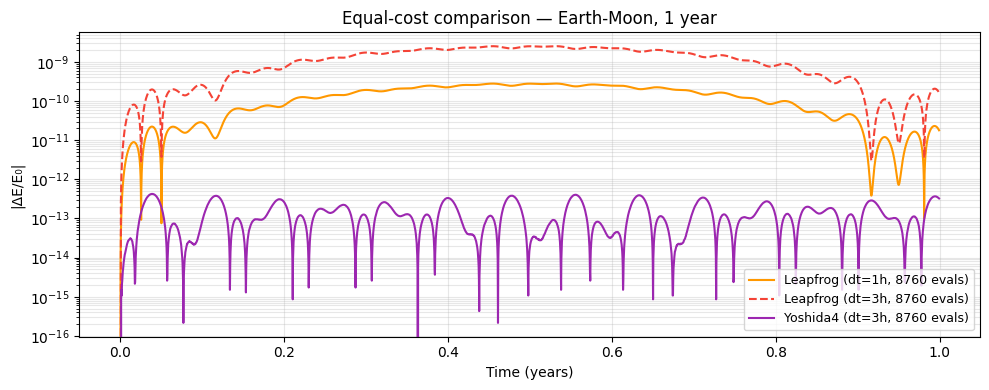

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.semilogy(t_years(r_lf_1h), drift(r_lf_1h), label='Leapfrog (dt=1h, 8760 evals)',
            color='#FF9800', linewidth=1.5)
ax.semilogy(t_years(r_lf_3h), drift(r_lf_3h), label='Leapfrog (dt=3h, 8760 evals)',
            color='#F44336', linewidth=1.5, linestyle='--')
ax.semilogy(t_years(r_y4_3h), drift(r_y4_3h), label='Yoshida4 (dt=3h, 8760 evals)',
            color='#9C27B0', linewidth=1.5)

ax.set_xlabel('Time (years)')
ax.set_ylabel('|ΔE/E₀|')
ax.set_title('Equal-cost comparison — Earth-Moon, 1 year')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 3 — Long-term drift: 10-year solar system

For short runs (1 year) both integrators are well within any practical accuracy bound.
The advantage of Yoshida4 compounds over longer timescales.

In [15]:
SOLAR = 'systems/solar_system_spice.json'
STEPS_10YR = 87600  # 10 years at dt=1h
STRIDE = 876        # sample every 36.5 days (100 points per decade)

print('Running 10-year solar system integrations...')
r_lf_10 = orbit.simulate(SOLAR, steps=STEPS_10YR, dt=3600.0,
                          integrator=orbit.Integrator.Leapfrog, stride=STRIDE)
print('  Leapfrog done')
r_y4_10 = orbit.simulate(SOLAR, steps=STEPS_10YR, dt=3600.0,
                          integrator=orbit.Integrator.Yoshida4, stride=STRIDE)
print('  Yoshida4 done')

t10_yr = np.array([s.time_s for s in r_lf_10.snapshots]) / YEAR

dE_lf10 = drift(r_lf_10)
dE_y410 = drift(r_y4_10)

print(f'\n10-year result (solar system, dt=1h):')
print(f'  Leapfrog  max |dE/E| = {np.max(dE_lf10):.3e}')
print(f'  Yoshida4  max |dE/E| = {np.max(dE_y410):.3e}')
print(f'  Improvement: {np.max(dE_lf10) / np.max(dE_y410):.0f}x')

Running 10-year solar system integrations...
  Leapfrog done
  Yoshida4 done

10-year result (solar system, dt=1h):
  Leapfrog  max |dE/E| = 4.280e-09
  Yoshida4  max |dE/E| = 8.120e-14
  Improvement: 52708x


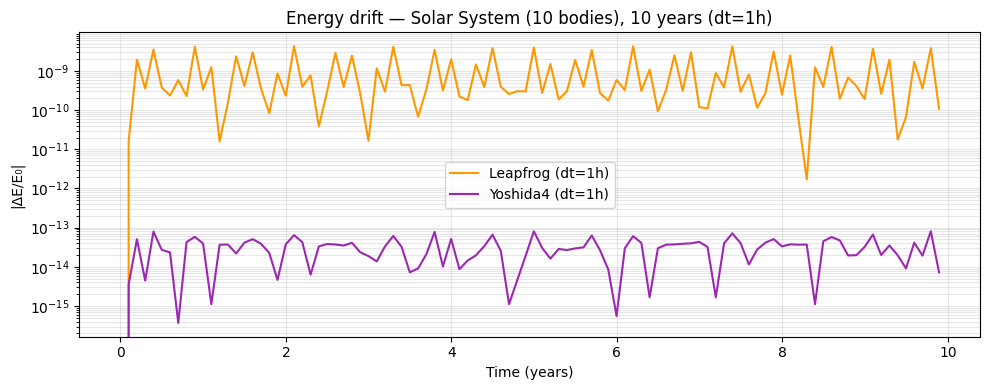

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.semilogy(t10_yr, dE_lf10, label='Leapfrog (dt=1h)', color='#FF9800', linewidth=1.5)
ax.semilogy(t10_yr, dE_y410, label='Yoshida4 (dt=1h)', color='#9C27B0', linewidth=1.5)

ax.set_xlabel('Time (years)')
ax.set_ylabel('|ΔE/E₀|')
ax.set_title('Energy drift — Solar System (10 bodies), 10 years (dt=1h)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 4 — Summary

### Energy drift (Earth-Moon, dt=1h, 1 year)

| Integrator | Order | Force evals/step | Max ΔE/E₀ |
|---|---|---|---|
| Leapfrog | 2nd | 1 | 2.80 × 10⁻¹⁰ |
| Yoshida4 | 4th | 3 | 4.50 × 10⁻¹⁴ |

**~6,200× improvement** at the same timestep and same system.

### Equal-cost comparison (same force evaluations per year, Earth-Moon)

| Integrator | dt | Max ΔE/E₀ |
|---|---|---|
| Leapfrog | 1h | 2.80 × 10⁻¹⁰ |
| Leapfrog | 3h | 2.52 × 10⁻⁹ |
| Yoshida4 | 3h | 4.24 × 10⁻¹³ |

Yoshida4 at 3h (same cost as Leapfrog at 1h) is still **660× better** than
Leapfrog at 1h. The 4th-order advantage dominates even after accounting for the
larger timestep.

### Long-term drift (Solar System, dt=1h, 10 years)

| Integrator | Max ΔE/E₀ over 10 years |
|---|---|
| Leapfrog | 4.28 × 10⁻⁹ |
| Yoshida4 | 8.12 × 10⁻¹⁴ |

**~52,700× improvement** over 10 years — the gap widens as the run lengthens.

### When does Yoshida4 matter?

| Timescale | Recommendation |
|---|---|
| < 10 years | Either integrator — drift negligible for education |
| 10–100 years | Yoshida4 preferred — drift diverges |
| > 100 years | Yoshida4 required for reliable results |
| > 10,000 years | Wisdom-Holman (future work) |

### SPICE accuracy

For the 1-year solar system SPICE validation, Yoshida4 gives the same ~88,000 km
Earth position error as all other integrators at dt=1h. At this timescale, the error
is dominated by **missing physics** (GR, J2) not integration method — all integrators
converge to the same physics-limited ceiling.

Yoshida4's advantage is **long-term phase-space fidelity**, not short-term absolute
accuracy.